<a href="https://colab.research.google.com/github/ASR16arif/Machine-Learning/blob/main/Cyber_Sentinel_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Cyber Sentinel: Unveiling Network Intruder with Convolutional Neural Network***

***Importing Libraries***

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [ ]:
# Install kaggle and required dependencies
!pip install Kaggle

In [ ]:
# Upload the Kaggle credentials
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asrarif","key":"be07789079edad86d416ac2615c24996"}'}

In [ ]:
# Create a directory and copy credentials
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

# ***Data Collection and Analysis***

In [ ]:
# Download the KDD CUP 1999 dataset from Kaggle
! kaggle datasets download -d galaxyh/kdd-cup-1999-data

Dataset URL: https://www.kaggle.com/datasets/galaxyh/kdd-cup-1999-data
License(s): unknown
 76% 67.0M/87.8M [00:00<00:00, 246MB/s]
100% 87.8M/87.8M [00:00<00:00, 254MB/s]


In [ ]:
# Download the CSE-CIC-IDS 2018 dataset from Kaggle
! kaggle datasets download -d solarmainframe/ids-intrusion-csv

Dataset URL: https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.60G/1.60G [00:09<00:00, 185MB/s]
100% 1.60G/1.60G [00:09<00:00, 183MB/s]


In [ ]:
# Unzip the KDD CUP 1999 dataset
!unzip kdd-cup-1999-data.zip

Archive:  kdd-cup-1999-data.zip
  inflating: corrected.gz            
  inflating: corrected/corrected     
  inflating: kddcup.data.corrected   
  inflating: kddcup.data.gz          
  inflating: kddcup.data/kddcup.data  
  inflating: kddcup.data_10_percent.gz  
  inflating: kddcup.data_10_percent/kddcup.data_10_percent  
  inflating: kddcup.data_10_percent_corrected  
  inflating: kddcup.names            
  inflating: kddcup.newtestdata_10_percent_unlabeled.gz  
  inflating: kddcup.newtestdata_10_percent_unlabeled/kddcup.newtestdata_10_percent_unlabeled  
  inflating: kddcup.testdata.unlabeled.gz  
  inflating: kddcup.testdata.unlabeled/kddcup.testdata.unlabeled  
  inflating: kddcup.testdata.unlabeled_10_percent.gz  
  inflating: kddcup.testdata.unlabeled_10_percent/kddcup.testdata.unlabeled_10_percent  
  inflating: training_attack_types   
  inflating: typo-correction.txt     


In [ ]:
# Unzip the CSE-CIC-IDS 2018 dataset
!unzip ids-intrusion-csv.zip

Archive:  ids-intrusion-csv.zip
  inflating: 02-14-2018.csv          
  inflating: 02-15-2018.csv          
  inflating: 02-16-2018.csv          
  inflating: 02-20-2018.csv          
  inflating: 02-21-2018.csv          
  inflating: 02-22-2018.csv          
  inflating: 02-23-2018.csv          
  inflating: 02-28-2018.csv          
  inflating: 03-01-2018.csv          
  inflating: 03-02-2018.csv          


In [ ]:
# Load the KDD CUP 1999 dataset
kdd_df = pd.read_csv('kddcup.data.gz', header=None)

In [ ]:
# Display the first 5 rows of KDD CUP 1999 dataset
print("KDD CUP 1999 Dataset :")
print(f"Columns in the dataset: {kdd_df.columns}")

kdd_df.head()

KDD CUP 1999 Dataset :
Columns in the dataset: Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41],
      dtype='int64')


,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal.


In [ ]:
# Assigning column names for KDD CUP 1999 dataset
kdd_df.columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

In [ ]:
# Display the first 5 rows of the KDD CUP 1999 dataset after assigning the column names
print("KDD CUP 1999 Dataset after assigning the column names:")
print(f"Columns in the dataset: {kdd_df.columns}")
kdd_df.head()

KDD CUP 1999 Dataset after assigning the column names:
Columns in the dataset: Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label'],
      dtype='object')


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,215,45076,0,0,0,0,...,0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,162,4528,0,0,0,0,...,1,1.0,0.0,1.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,236,1228,0,0,0,0,...,2,1.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,233,2032,0,0,0,0,...,3,1.0,0.0,0.33,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,239,486,0,0,0,0,...,4,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,normal.


In [ ]:
# Count the occurrences of each label in kdd_df
label_counts = kdd_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
smurf.: 2807886
neptune.: 1072017
normal.: 972781
satan.: 15892
ipsweep.: 12481
portsweep.: 10413
nmap.: 2316
back.: 2203
warezclient.: 1020
teardrop.: 979
pod.: 264
guess_passwd.: 53
buffer_overflow.: 30
land.: 21
warezmaster.: 20
imap.: 12
rootkit.: 10
loadmodule.: 9
ftp_write.: 8
multihop.: 7
phf.: 4
perl.: 3
spy.: 2


In [ ]:
# Load the CSE-CIC-IDS 2018 dataset
cic_df1 = pd.read_csv('02-14-2018.csv')
cic_df2 = pd.read_csv('02-15-2018.csv')
cic_df3 = pd.read_csv('02-16-2018.csv')
cic_df4 = pd.read_csv('02-20-2018.csv')
cic_df5 = pd.read_csv('02-21-2018.csv')
cic_df6 = pd.read_csv('02-22-2018.csv')
cic_df7 = pd.read_csv('02-23-2018.csv')
cic_df8 = pd.read_csv('02-28-2018.csv')
cic_df9 = pd.read_csv('03-01-2018.csv')
cic_df10 = pd.read_csv('03-02-2018.csv')

<ipython-input-14-f971391948fb>:4: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  cic_df3 = pd.read_csv('02-16-2018.csv')
<ipython-input-14-f971391948fb>:9: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  cic_df8 = pd.read_csv('02-28-2018.csv')
<ipython-input-14-f971391948fb>:10: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,

In [ ]:
# Merging all individual CSE-CIC-IDS 2018 datasets into one DataFrame
cic_df = pd.concat([cic_df1, cic_df2, cic_df3, cic_df4, cic_df5, cic_df6, cic_df7, cic_df8, cic_df9, cic_df10], ignore_index=True)

In [ ]:
# Display the first 5 rows of the CSE-CIC-IDS 2018 dataset
print("CSE-CIC-IDS 2018 Dataset:")
print(f"Columns in the dataset: {cic_df.columns}")
cic_df.head()

CSE-CIC-IDS 2018 Dataset:
Columns in the dataset: Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,56320859.5,139.300036,56320958,56320761,Benign,NaN,NaN,NaN,NaN
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,56320733.0,114.551299,56320814,56320652,Benign,NaN,NaN,NaN,NaN
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,56319311.5,301.934596,56319525,56319098,Benign,NaN,NaN,NaN,NaN
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN


# ***Data Preprocessing***

In [ ]:
# Define mapping to align CIC column names to KDD column names
column_mapping = {
    'Flow Duration': 'duration',
    'Protocol': 'protocol_type',
    'Dst Port': 'dst_bytes',
    'Tot Fwd Pkts': 'count',
    'Tot Bwd Pkts': 'srv_count',
    'Fwd Pkt Len Max': 'serror_rate',
    'Fwd Pkt Len Min': 'srv_serror_rate',
    'Bwd Pkt Len Max': 'rerror_rate',
    'Bwd Pkt Len Min': 'srv_rerror_rate',
    'Fwd Pkt Len Mean': 'same_srv_rate',
    'Bwd Pkt Len Mean': 'diff_srv_rate',
    'Flow IAT Mean': 'srv_diff_host_rate',
    'Flow IAT Std': 'dst_host_count',
    'Flow IAT Max': 'dst_host_srv_count',
    'Flow IAT Min': 'dst_host_same_srv_rate',
    'Fwd IAT Tot': 'dst_host_diff_srv_rate',
    'Fwd IAT Mean': 'dst_host_same_src_port_rate',
    'Fwd IAT Std': 'dst_host_srv_diff_host_rate',
    'Bwd IAT Tot': 'dst_host_serror_rate',
    'Bwd IAT Mean': 'dst_host_srv_serror_rate',
    'Bwd IAT Std': 'dst_host_rerror_rate',
    'Fwd PSH Flags': 'dst_host_srv_rerror_rate',
    'Bwd PSH Flags': 'land',
    'Fwd URG Flags': 'urgent',
    'Bwd URG Flags': 'wrong_fragment',
    'Fwd Header Len': 'num_failed_logins',
    'Bwd Header Len': 'logged_in',
    'Fwd Pkts/s': 'hot',
    'Bwd Pkts/s': 'num_compromised',
    'Pkt Len Max': 'root_shell',
    'Pkt Len Min': 'su_attempted',
    'Pkt Len Mean': 'num_root',
    'Pkt Len Std': 'num_file_creations',
    'Pkt Len Var': 'num_shells',
    'TotLen Fwd Pkts': 'num_access_files',
    'TotLen Bwd Pkts': 'num_outbound_cmds',
    'Avg Fwd Segment Size': 'is_host_login',
    'Avg Bwd Segment Size': 'is_guest_login',
    'Label': 'label'
}

In [ ]:
# Rename columns in CIC dataset
cic_df.rename(columns=column_mapping, inplace=True)

In [ ]:
# Display the first 5 rows of the CSE-CIC-IDS 2018 dataset after renaming the column names
print("CSE-CIC-IDS 2018 Dataset after renaming the column names:")
print(f"Columns in the dataset: {cic_df.columns}")
cic_df.head()

CSE-CIC-IDS 2018 Dataset after renaming the column names:
Columns in the dataset: Index(['dst_bytes', 'protocol_type', 'Timestamp', 'duration', 'count',
       'srv_count', 'num_access_files', 'num_outbound_cmds', 'serror_rate',
       'srv_serror_rate', 'same_srv_rate', 'Fwd Pkt Len Std', 'rerror_rate',
       'srv_rerror_rate', 'diff_srv_rate', 'Bwd Pkt Len Std', 'Flow Byts/s',
       'Flow Pkts/s', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'Fwd IAT Max', 'Fwd IAT Min',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'Bwd IAT Max', 'Bwd IAT Min',
       'dst_host_srv_rerror_rate', 'land', 'urgent', 'wrong_fragment',
       'num_failed_logins', 'logged_in', 'hot', 'num_compromised',
       'su_attempted', 'root_shell', 'num_root', 'num_file_creations',
       'num_shells', 'FIN Flag Cnt', 'S

,dst_bytes,protocol_type,Timestamp,duration,count,srv_count,num_access_files,num_outbound_cmds,serror_rate,srv_serror_rate,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label,Flow ID,Src IP,Src Port,Dst IP
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,56320859.5,139.300036,56320958,56320761,Benign,NaN,NaN,NaN,NaN
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,56320733.0,114.551299,56320814,56320652,Benign,NaN,NaN,NaN,NaN
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,56319311.5,301.934596,56319525,56319098,Benign,NaN,NaN,NaN,NaN
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN


In [ ]:
# Count the occurrences of each label in cic_df
label_counts = cic_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
Benign: 13484708
DDOS attack-HOIC: 686012
DDoS attacks-LOIC-HTTP: 576191
DoS attacks-Hulk: 461912
Bot: 286191
FTP-BruteForce: 193360
SSH-Bruteforce: 187589
Infilteration: 161934
DoS attacks-SlowHTTPTest: 139890
DoS attacks-GoldenEye: 41508
DoS attacks-Slowloris: 10990
DDOS attack-LOIC-UDP: 1730
Brute Force -Web: 611
Brute Force -XSS: 230
SQL Injection: 87
Label: 59


In [ ]:
# Define the categorization for KDD dataset attacks
kdd_attack_levels = {
    'smurf.': 'low-level attack',
    'neptune.': 'low-level attack',
    'satan.': 'low-level attack',
    'ipsweep.': 'low-level attack',
    'portsweep.': 'low-level attack',
    'nmap.': 'low-level attack',
    'back.': 'low-level attack',
    'warezclient.': 'low-level attack',
    'teardrop.': 'low-level attack',
    'pod.': 'low-level attack',
    'guess_passwd.': 'high-level attack',
    'buffer_overflow.': 'high-level attack',
    'land.': 'low-level attack',
    'warezmaster.': 'low-level attack',
    'imap.': 'low-level attack',
    'rootkit.': 'high-level attack',
    'loadmodule.': 'high-level attack',
    'ftp_write.': 'high-level attack',
    'multihop.': 'high-level attack',
    'phf.': 'high-level attack',
    'perl.': 'high-level attack',
    'spy.': 'high-level attack',
    'normal.': 'normal',
}

In [ ]:
# Update KDD labels based on the defined levels, replacing unmapped or unknown labels with 0
kdd_df['label'] = kdd_df['label'].map(kdd_attack_levels).fillna(0)

In [ ]:
# Count the occurrences of each label in kdd_df after categorize the attack levels
label_counts = kdd_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
low-level attack: 3925524
normal: 972781
high-level attack: 126


In [ ]:
# Define the categorization for CIC dataset attacks
cic_attack_levels = {
    'Benign': 'normal',
    'DDOS attack-HOIC': 'high-level attack',
    'DDoS attacks-LOIC-HTTP': 'high-level attack',
    'DoS attacks-Hulk': 'low-level attack',
    'Bot': 'low-level attack',
    'FTP-BruteForce': 'low-level attack',
    'SSH-Bruteforce': 'low-level attack',
    'Infilteration': 'high-level attack',
    'DoS attacks-SlowHTTPTest': 'low-level attack',
    'DoS attacks-GoldenEye': 'low-level attack',
    'DoS attacks-Slowloris': 'low-level attack',
    'DDOS attack-LOIC-UDP': 'high-level attack',
    'Brute Force -Web': 'high-level attack',
    'Brute Force -XSS': 'high-level attack',
    'SQL Injection': 'high-level attack',
    'Label': 'unknown',
}

In [ ]:
# Update CIC labels based on the defined levels, replacing unmapped or unknown labels with 0
cic_df['label'] = cic_df['label'].map(cic_attack_levels).fillna(0)

In [ ]:
# Count the occurrences of each label in cic_df after categorize the attack levels
label_counts = cic_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
normal: 13484708
high-level attack: 1426795
low-level attack: 1321440
unknown: 59


In [ ]:
# Convert 'unknown' labels to 0
cic_df['label'] = cic_df['label'].replace('unknown', 0)

In [ ]:
# Count the occurrences of each label in cic_df after Converting 'unknown' labels to 0
label_counts = cic_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
normal: 13484708
high-level attack: 1426795
low-level attack: 1321440
0: 59


In [ ]:
# Find common columns in both DataFrames
common_columns = list(set(kdd_df.columns) & set(cic_df.columns))

# Select only the common columns from kdd_df
kdd_df = kdd_df[common_columns]

# Select only the common columns from cic_df
cic_df = cic_df[common_columns]

In [ ]:
# Shuffle and reset the index for consistency
kdd_df = shuffle(kdd_df).reset_index(drop=True)
cic_df = shuffle(cic_df).reset_index(drop=True)

In [ ]:
# Display the first 5 rows of the KDD CUP 1999 dataset after shuffling
print("KDD CUP 1999 Dataset after shuffling:")
kdd_df.head()

KDD CUP 1999 Dataset after shuffling:


,same_srv_rate,dst_host_srv_diff_host_rate,srv_rerror_rate,dst_host_count,num_access_files,dst_host_srv_count,hot,num_shells,su_attempted,logged_in,...,duration,dst_host_serror_rate,dst_bytes,root_shell,dst_host_same_src_port_rate,dst_host_diff_srv_rate,srv_count,dst_host_rerror_rate,urgent,srv_diff_host_rate
0,1.00,0.16,0.0,6,0,32,0,0,0,1,...,0,0.0,0,0,0.17,0.33,1,0.0,0,0.0
1,1.00,0.00,0.0,255,0,255,0,0,0,0,...,0,0.0,0,0,1.00,0.00,478,0.0,0,0.0
2,0.03,0.00,1.0,255,0,7,0,0,0,0,...,0,0.0,0,0,0.00,0.07,7,1.0,0,0.0
3,0.06,0.00,0.0,255,0,16,0,0,0,0,...,0,1.0,0,0,0.00,0.05,16,0.0,0,0.0
4,0.09,0.00,0.0,255,0,13,0,0,0,0,...,0,1.0,0,0,0.00,0.07,13,0.0,0,0.0


In [ ]:
# Display the first 5 rows of the CSE-CIC-IDS 2018 dataset after shuffling
print("CSE-CIC-IDS 2018 Dataset after shuffling:")
cic_df.head()

CSE-CIC-IDS 2018 Dataset after shuffling:


,same_srv_rate,dst_host_srv_diff_host_rate,srv_rerror_rate,dst_host_count,num_access_files,dst_host_srv_count,hot,num_shells,su_attempted,logged_in,...,duration,dst_host_serror_rate,dst_bytes,root_shell,dst_host_same_src_port_rate,dst_host_diff_srv_rate,srv_count,dst_host_rerror_rate,urgent,srv_diff_host_rate
0,24.25,35555.012253,0,1792354.933415,97,4752092,0.830876,6400.777778,0,92,...,4814197,4814005,80,232,20701.666667,62105,4,2778896.831516,0,687742.428571
1,45.0,0.0,61,0.0,45,271,3690.0369,85.333333,45,8,...,271,0,53,61,0.0,0,1,0.0,0,271.0
2,0.0,0.0,0,1091.77287,0,1544.0,647.668394,0.0,0,40,...,1544,0.0,443,0,0.0,0.0,2,0.0,0,772.0
3,53.666667,121.622366,0,99.188205,161,267,3484.320557,30202.125,0,92,...,861,594,80,488,235.0,470,4,192.657728,0,143.5
4,0.0,92744.12542,0,88762.00779,0,169267,14.458667,0.0,0,28,...,207488,0,445,0,103744.0,207488,1,0.0,0,69162.66667


# Data ***Concatenation***

In [ ]:
# Merge datasets
merged_df = pd.concat([kdd_df, cic_df], ignore_index=True)

In [ ]:
# Verify the merged dataset
print("Merged Dataset:")
print(f"Columns in the merged dataset: {merged_df.columns}")
print(f"Shape of merged dataset: {merged_df.shape}")
merged_df.head()

Merged Dataset:
Columns in the merged dataset: Index(['same_srv_rate', 'dst_host_srv_diff_host_rate', 'srv_rerror_rate',
       'dst_host_count', 'num_access_files', 'dst_host_srv_count', 'hot',
       'num_shells', 'su_attempted', 'logged_in', 'num_file_creations',
       'dst_host_srv_serror_rate', 'serror_rate', 'num_compromised', 'land',
       'label', 'dst_host_same_srv_rate', 'wrong_fragment', 'diff_srv_rate',
       'dst_host_srv_rerror_rate', 'num_failed_logins', 'num_outbound_cmds',
       'count', 'protocol_type', 'num_root', 'rerror_rate', 'srv_serror_rate',
       'duration', 'dst_host_serror_rate', 'dst_bytes', 'root_shell',
       'dst_host_same_src_port_rate', 'dst_host_diff_srv_rate', 'srv_count',
       'dst_host_rerror_rate', 'urgent', 'srv_diff_host_rate'],
      dtype='object')
Shape of merged dataset: (21131433, 37)


,same_srv_rate,dst_host_srv_diff_host_rate,srv_rerror_rate,dst_host_count,num_access_files,dst_host_srv_count,hot,num_shells,su_attempted,logged_in,...,duration,dst_host_serror_rate,dst_bytes,root_shell,dst_host_same_src_port_rate,dst_host_diff_srv_rate,srv_count,dst_host_rerror_rate,urgent,srv_diff_host_rate
0,1.0,0.16,0.0,6,0,32,0,0,0,1,...,0,0.0,0,0,0.17,0.33,1,0.0,0,0.0
1,1.0,0.0,0.0,255,0,255,0,0,0,0,...,0,0.0,0,0,1.0,0.0,478,0.0,0,0.0
2,0.03,0.0,1.0,255,0,7,0,0,0,0,...,0,0.0,0,0,0.0,0.07,7,1.0,0,0.0
3,0.06,0.0,0.0,255,0,16,0,0,0,0,...,0,1.0,0,0,0.0,0.05,16,0.0,0,0.0
4,0.09,0.0,0.0,255,0,13,0,0,0,0,...,0,1.0,0,0,0.0,0.07,13,0.0,0,0.0


In [ ]:
# Ensure numeric data for relevant columns
numeric_columns = ['dst_bytes', 'duration', 'srv_count', 'dst_host_count', 'rerror_rate', 'serror_rate']
for col in numeric_columns:
    # Convert to numeric, replace NaN with 0
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').fillna(0)

In [ ]:
# Add new derived features for enhanced analysis
merged_df['bytes_ratio'] = merged_df['dst_bytes'] / (merged_df['duration'] + 1)  # Avoid division by zero
merged_df['srv_to_host_ratio'] = merged_df['srv_count'] / (merged_df['dst_host_count'] + 1)
merged_df['rerror_to_serror_ratio'] = merged_df['rerror_rate'] / (merged_df['serror_rate'] + 1)

In [ ]:
# Verify the merged dataset after adding new derived features
print("Merged Dataset after adding new derived features:")
print(f"Columns in the merged dataset: {merged_df.columns}")
print(f"Shape of merged dataset: {merged_df.shape}")
merged_df.head()

Merged Dataset after adding new derived features:
Columns in the merged dataset: Index(['same_srv_rate', 'dst_host_srv_diff_host_rate', 'srv_rerror_rate',
       'dst_host_count', 'num_access_files', 'dst_host_srv_count', 'hot',
       'num_shells', 'su_attempted', 'logged_in', 'num_file_creations',
       'dst_host_srv_serror_rate', 'serror_rate', 'num_compromised', 'land',
       'label', 'dst_host_same_srv_rate', 'wrong_fragment', 'diff_srv_rate',
       'dst_host_srv_rerror_rate', 'num_failed_logins', 'num_outbound_cmds',
       'count', 'protocol_type', 'num_root', 'rerror_rate', 'srv_serror_rate',
       'duration', 'dst_host_serror_rate', 'dst_bytes', 'root_shell',
       'dst_host_same_src_port_rate', 'dst_host_diff_srv_rate', 'srv_count',
       'dst_host_rerror_rate', 'urgent', 'srv_diff_host_rate', 'bytes_ratio',
       'srv_to_host_ratio', 'rerror_to_serror_ratio'],
      dtype='object')
Shape of merged dataset: (21131433, 40)


,same_srv_rate,dst_host_srv_diff_host_rate,srv_rerror_rate,dst_host_count,num_access_files,dst_host_srv_count,hot,num_shells,su_attempted,logged_in,...,root_shell,dst_host_same_src_port_rate,dst_host_diff_srv_rate,srv_count,dst_host_rerror_rate,urgent,srv_diff_host_rate,bytes_ratio,srv_to_host_ratio,rerror_to_serror_ratio
0,1.0,0.16,0.0,6.0,0,32,0,0,0,1,...,0,0.17,0.33,1.0,0.0,0,0.0,0.0,0.142857,0.0
1,1.0,0.0,0.0,255.0,0,255,0,0,0,0,...,0,1.0,0.0,478.0,0.0,0,0.0,0.0,1.867188,0.0
2,0.03,0.0,1.0,255.0,0,7,0,0,0,0,...,0,0.0,0.07,7.0,1.0,0,0.0,0.0,0.027344,1.0
3,0.06,0.0,0.0,255.0,0,16,0,0,0,0,...,0,0.0,0.05,16.0,0.0,0,0.0,0.0,0.062500,0.0
4,0.09,0.0,0.0,255.0,0,13,0,0,0,0,...,0,0.0,0.07,13.0,0.0,0,0.0,0.0,0.050781,0.0


In [ ]:
# Ensure 'label' is the last columns
columns_except_label = [col for col in merged_df.columns if col not in ['label']]
final_columns_order = columns_except_label + ['label']

In [ ]:
# Reorder the DataFrame
merged_df = merged_df[final_columns_order]

In [ ]:
# Verify the merged dataset after reorganizing the columns
print("Merged Dataset after reorganizing the columns:")
print(f"Columns in the merged dataset: {merged_df.columns}")
print(f"Shape of merged dataset: {merged_df.shape}")
merged_df.head()

Merged Dataset after reorganizing the columns:
Columns in the merged dataset: Index(['same_srv_rate', 'dst_host_srv_diff_host_rate', 'srv_rerror_rate',
       'dst_host_count', 'num_access_files', 'dst_host_srv_count', 'hot',
       'num_shells', 'su_attempted', 'logged_in', 'num_file_creations',
       'dst_host_srv_serror_rate', 'serror_rate', 'num_compromised', 'land',
       'dst_host_same_srv_rate', 'wrong_fragment', 'diff_srv_rate',
       'dst_host_srv_rerror_rate', 'num_failed_logins', 'num_outbound_cmds',
       'count', 'protocol_type', 'num_root', 'rerror_rate', 'srv_serror_rate',
       'duration', 'dst_host_serror_rate', 'dst_bytes', 'root_shell',
       'dst_host_same_src_port_rate', 'dst_host_diff_srv_rate', 'srv_count',
       'dst_host_rerror_rate', 'urgent', 'srv_diff_host_rate', 'bytes_ratio',
       'srv_to_host_ratio', 'rerror_to_serror_ratio', 'label'],
      dtype='object')
Shape of merged dataset: (21131433, 40)


,same_srv_rate,dst_host_srv_diff_host_rate,srv_rerror_rate,dst_host_count,num_access_files,dst_host_srv_count,hot,num_shells,su_attempted,logged_in,...,dst_host_same_src_port_rate,dst_host_diff_srv_rate,srv_count,dst_host_rerror_rate,urgent,srv_diff_host_rate,bytes_ratio,srv_to_host_ratio,rerror_to_serror_ratio,label
0,1.0,0.16,0.0,6.0,0,32,0,0,0,1,...,0.17,0.33,1.0,0.0,0,0.0,0.0,0.142857,0.0,normal
1,1.0,0.0,0.0,255.0,0,255,0,0,0,0,...,1.0,0.0,478.0,0.0,0,0.0,0.0,1.867188,0.0,low-level attack
2,0.03,0.0,1.0,255.0,0,7,0,0,0,0,...,0.0,0.07,7.0,1.0,0,0.0,0.0,0.027344,1.0,low-level attack
3,0.06,0.0,0.0,255.0,0,16,0,0,0,0,...,0.0,0.05,16.0,0.0,0,0.0,0.0,0.062500,0.0,low-level attack
4,0.09,0.0,0.0,255.0,0,13,0,0,0,0,...,0.0,0.07,13.0,0.0,0,0.0,0.0,0.050781,0.0,low-level attack


In [ ]:
# Count the occurrences of each label in merged_df
label_counts = merged_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
normal: 14457489
low-level attack: 5246964
high-level attack: 1426921
0: 59


In [ ]:
# Drop rows where the label column has a value of 0
merged_df = merged_df[merged_df['label'] != 0]

In [ ]:
# Count the occurrences of each label in merged_df after dropping the rows where the label column has a value of 0
label_counts = merged_df['label'].value_counts()

# Display the Label Type and Count
print("Label Type and Count:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Type and Count:
normal: 14457489
low-level attack: 5246964
high-level attack: 1426921


In [ ]:
# Shuffle and reset the index for consistency
merged_df = shuffle(merged_df).reset_index(drop=True)

In [ ]:
# Verify the merged dataset after shuffling
print("Merged Dataset after shuffling:")
merged_df.head()

Merged Dataset after shuffling:


,same_srv_rate,dst_host_srv_diff_host_rate,srv_rerror_rate,dst_host_count,num_access_files,dst_host_srv_count,hot,num_shells,su_attempted,logged_in,...,dst_host_same_src_port_rate,dst_host_diff_srv_rate,srv_count,dst_host_rerror_rate,urgent,srv_diff_host_rate,bytes_ratio,srv_to_host_ratio,rerror_to_serror_ratio,label
0,49.333333,128.693434,0,111.945969,148,276,3278.688525,8834.696429,0,92,...,223.0,446,4.0,195.152077,0,152.5,0.087336,0.035415,1.630872,normal
1,0.0,0.0,0,0.000000,0,79,25316.455696,0.0,0,0,...,79.0,79,0.0,0.0,0,79.0,1.000000,0.000000,0.000000,normal
2,0.0,0.0,0,0.000000,0,35,57142.857143,0.0,0,0,...,35.0,35,0.0,0.0,0,35.0,1553.833333,0.000000,0.000000,normal
3,143.5,401038.230539,0,250179.201422,1148,963510,3.710499,102037.595833,0,152,...,308006.285714,2156044,7.0,311912.243439,0,154003.142857,0.001572,0.000028,1.730088,normal
4,0.0,0.0,0.0,0.000000,0.0,36.0,55555.555556,0.0,0.0,0,...,36.0,36.0,0.0,0.0,0,36.0,825.459459,0.000000,0.000000,normal


# ***Data Processing***

In [ ]:
# Define the custom label mapping
custom_label_order = ['normal', 'low-level attack', 'high-level attack']

# Map the 'label' column to the custom order
merged_df['label'] = merged_df['label'].map(lambda x: custom_label_order.index(x))

# Verify the label encoding
print("Encoded labels and their counts:")
print(merged_df['label'].value_counts().sort_index())

Encoded labels and their counts:
label
0    14457489
1     5246964
2     1426921
Name: count, dtype: int64


In [ ]:
# Identify categorical columns
categorical_columns = ['protocol_type']

for col in categorical_columns:
    merged_df[col] = merged_df[col].astype(str)
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])

In [ ]:
from collections import Counter

# Print the unique label types
print("Unique labels after encoding:", sorted(merged_df['label'].unique()))

# Count the occurrences of each label
label_counts = Counter(merged_df['label'])
print("\nLabel counts:")
for label, count in label_counts.items():
    print(f"Label {label}: {count} occurrences")

Unique labels after encoding: [0, 1, 2]

Label counts:
Label 0: 14457489 occurrences
Label 1: 5246964 occurrences
Label 2: 1426921 occurrences


In [ ]:
# Separate features (X) and labels (y)
X = merged_df.drop('label', axis=1).apply(pd.to_numeric, errors='coerce').fillna(0).values
y = merged_df['label'].values  # Keep the label column as target

In [ ]:
# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# One-hot encode the labels
y = to_categorical(y)

***Split the Dataset into Training and Testing sets***

In [ ]:
# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ***CNN Model Design and Training***

***Model Design***

In [ ]:
# Build the CNN model
model = Sequential([
    # First convolutional layer
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    # First max pooling layer
    MaxPooling1D(pool_size=2),
    # Dropout layer for regularization
    Dropout(0.3),
    # Second convolutional layer
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    # Second max pooling layer
    MaxPooling1D(pool_size=2),
    # Dropout layer for regularization
    Dropout(0.4),
    # Third convolutional layer
    Conv1D(filters=256, kernel_size=3, activation='relu'),
    # Third max pooling layer
    MaxPooling1D(pool_size=2),
    # Dropout layer for regularization
    Dropout(0.4),
    # Flatten layer
    Flatten(),
    # Fully connected dense layer
    Dense(256, activation='relu'),
    # Dropout layer
    Dropout(0.5),
    # Output layer with softmax activation
    Dense(y_train.shape[1], activation='softmax')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 37, 64)            256       
                                                                 
 max_pooling1d (MaxPooling1  (None, 18, 64)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 18, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 16, 128)           24704     
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 8, 128)            0         
 g1D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 8, 128)            0

In [ ]:
# Reshape the data for CNN input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

***Model Training***

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/20
264143/264143 [==============================] - 2880s 11ms/step - loss: 0.1884 - accuracy: 0.9329 - val_loss: 0.1405 - val_accuracy: 0.9391
Epoch 2/20
264143/264143 [==============================] - 2862s 11ms/step - loss: 0.4814 - accuracy: 0.9307 - val_loss: 0.1439 - val_accuracy: 0.9339
Epoch 3/20
264143/264143 [==============================] - 2866s 11ms/step - loss: 0.5573 - accuracy: 0.9279 - val_loss: 0.1445 - val_accuracy: 0.9358
Epoch 4/20
264143/264143 [==============================] - 2861s 11ms/step - loss: 0.2056 - accuracy: 0.9264 - val_loss: 0.1571 - val_accuracy: 0.9256
Epoch 5/20
264143/264143 [==============================] - 2860s 11ms/step - loss: 0.1967 - accuracy: 0.9259 - val_loss: 0.1493 - val_accuracy: 0.9332
Epoch 6/20
264143/264143 [==============================] - 2859s 11ms/step - loss: 0.4273 - accuracy: 0.9255 - val_loss: 0.1469 - val_accuracy: 0.9326
Epoch 7/20
264143/264143 [==============================] - 2863s 11ms/step - loss: 0.35

# ***Model Evaluation***

In [ ]:
# Evaluate the model
y_pred = np.argmax(model.predict(X_test), axis=-1)
y_test_labels = np.argmax(y_test, axis=1)

132072/132072 [==============================] - 387s 3ms/step


In [ ]:
# Classification report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95   2891092
           1       1.00      0.86      0.92   1049711
           2       0.96      0.49      0.65    285472

    accuracy                           0.93   4226275
   macro avg       0.96      0.78      0.84   4226275
weighted avg       0.93      0.93      0.92   4226275



In [ ]:
# Classification report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred, target_names=['Normal', 'Low-Level Attack', 'High-Level Attack']))

Classification Report:
                   precision    recall  f1-score   support

           Normal       0.91      1.00      0.95   2891092
 Low-Level Attack       1.00      0.86      0.92   1049711
High-Level Attack       0.96      0.49      0.65    285472

         accuracy                           0.93   4226275
        macro avg       0.96      0.78      0.84   4226275
     weighted avg       0.93      0.93      0.92   4226275



***Importing Libraries***

In [87]:
# Import necessary libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from PIL import Image
import io
from IPython.display import display

In [85]:
# Evaluate model performance
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")

132072/132072 [==============================] - 407s 3ms/step - loss: 19.0257 - accuracy: 0.9301
Test Accuracy: 0.9301304221153259


In [88]:
# Calculate metrics
accuracy = accuracy_score(y_test_labels, y_pred)
precision = precision_score(y_test_labels, y_pred, average='weighted')
recall = recall_score(y_test_labels, y_pred, average='weighted')
f1 = f1_score(y_test_labels, y_pred, average='weighted')

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.9301
Precision: 0.9347
Recall: 0.9301
F1-Score: 0.9246


# ***Data Visualization and Analysis***

***Confusion Matrix***

In [97]:
# Confusion matrix
cm = confusion_matrix(y_test.argmax(axis=1), y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

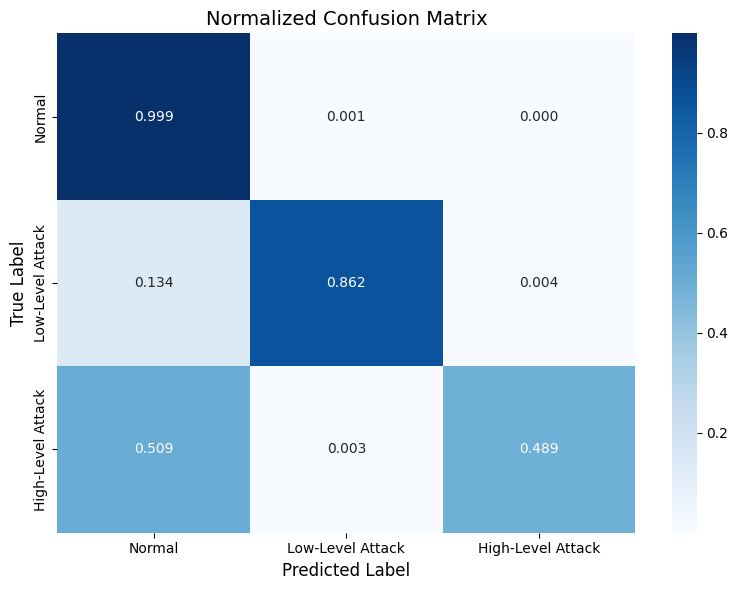

In [99]:
# Define labels for each class
labels = ['Normal', 'Low-Level Attack', 'High-Level Attack']

# Plot normalized confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
plt.title('Normalized Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [100]:
# Print classification metrics
accuracy = accuracy_score(y_test.argmax(axis=1), y_pred)
precision = precision_score(y_test.argmax(axis=1), y_pred, average='weighted')
recall = recall_score(y_test.argmax(axis=1), y_pred, average='weighted')
f1 = f1_score(y_test.argmax(axis=1), y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test.argmax(axis=1), y_pred, target_names=labels))

Accuracy: 0.9301
Precision: 0.9347
Recall: 0.9301
F1-Score: 0.9246

Classification Report:
                   precision    recall  f1-score   support

           Normal       0.91      1.00      0.95   2891092
 Low-Level Attack       1.00      0.86      0.92   1049711
High-Level Attack       0.96      0.49      0.65    285472

         accuracy                           0.93   4226275
        macro avg       0.96      0.78      0.84   4226275
     weighted avg       0.93      0.93      0.92   4226275



***Correlation Matrix***

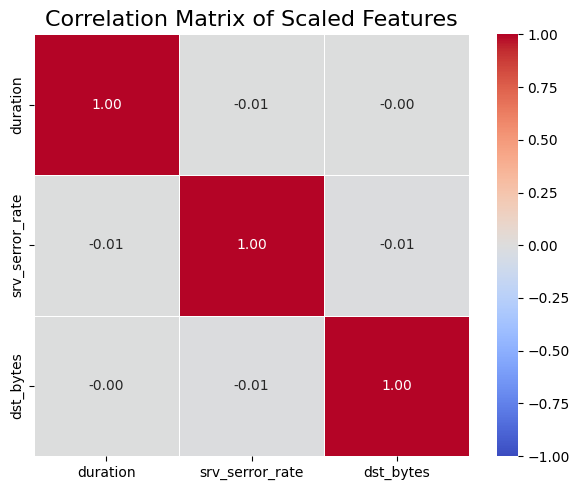

In [115]:
# Select features for the correlation matrix
selected_features = ['duration', 'srv_serror_rate', 'dst_bytes']

# Extract the columns
features = merged_df[selected_features]

# Compute the correlation matrix for the selected features
corr_matrix= features.corr()

# Plot the 3x3 correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Scaled Features', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

***Frequency Distribution***

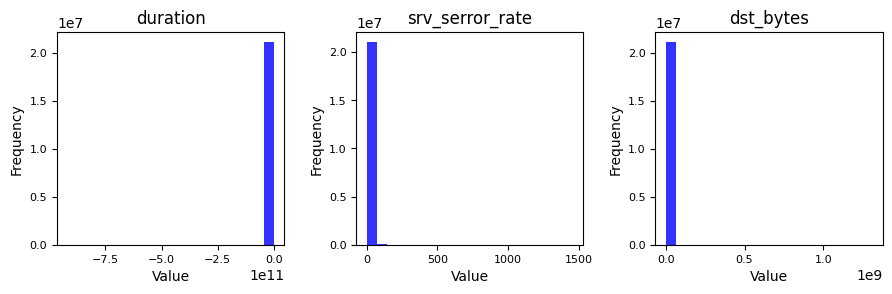

In [121]:
# Ploting the Frequency Distribution of Features in Training Set
plt.figure(figsize=(18, 16))

for i, feature in enumerate(features.columns, start=1):
    plt.subplot(6, 6, i)

    # Convert the feature data to numeric, handling errors and filling NaNs
    numeric_data = pd.to_numeric(features[feature], errors='coerce').fillna(0)

    # Plot the histogram
    plt.hist(numeric_data, bins=20, color='blue', alpha=0.8)
    plt.title(f'{feature}', fontsize=12)
    plt.xlabel('Value', fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Display the plots
plt.show()

***Training/Validation Accuracy and Loss***

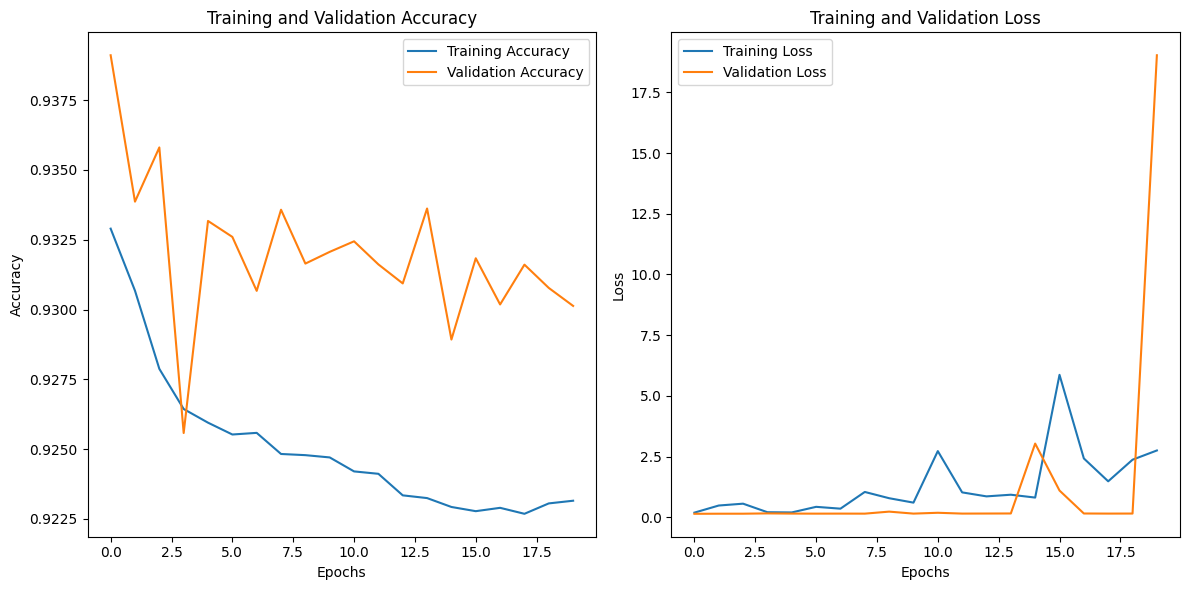

In [122]:
# Plotting the training/validation accuracy and loss

plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()